# One-day Value-at-Risk with analogue-conditioned filtered historical simulation

Filtered historical simulation (FHS) rescales past standardised shocks by today's GARCH volatility.
The analogue variant uses only the shocks that followed *similar volatility states*. This tutorial
runs the walk-forward comparison on the S&P 500 and backtests the 1% VaR.

In [1]:
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e4e3df", "font.size": 9})
BLUE, ORANGE, AQUA, INK2 = "#2a78d6", "#eb6834", "#1baf7a", "#52514e"

In [2]:
import numpy as np
from analogue_risk import data, model as M, vol as V, var as R
from analogue_risk.experiments import split, var_config

mkt = M.Market(data.yahoo("^GSPC", start="1927-12-30"))
cfg = var_config(mkt.n)                  # 250 analogues per regime for long series
d = V.VolData(mkt, cfg.vol())
cal, folds = split(mkt.n, cfg.vol().warmup)
out = R.forecasts(d, cfg, folds)         # walk-forward: every fit uses only earlier data
y = np.r_[d.r[1:], np.nan]               # next-day log return

In [3]:
a = 0.01
ok = np.zeros(mkt.n, bool); ok[cal:] = True; ok &= np.isfinite(y)
for name in ("GARCH-N", "GARCH-t", "FHS", "Analogue"):
    v, e = out[name][a]
    m = ok & np.isfinite(v) & np.isfinite(e)
    hits = y[m] <= v[m]
    print(f"{name:9s} breach rate {hits.mean():.4f} (target {a})   Kupiec p {R.kupiec(hits, a)[1]:.2f}   "
          f"Christoffersen CC p {R.christoffersen(hits, a)[1]:.2f}   FZ0 {R.fz0_loss(y[m], v[m], e[m], a).mean():.4f}")

GARCH-N   breach rate 0.0156 (target 0.01)   Kupiec p 0.00   Christoffersen CC p 0.00   FZ0 -3.4751
GARCH-t   breach rate 0.0102 (target 0.01)   Kupiec p 0.80   Christoffersen CC p 0.04   FZ0 -3.5312
FHS       breach rate 0.0084 (target 0.01)   Kupiec p 0.03   Christoffersen CC p 0.00   FZ0 -3.5253
Analogue  breach rate 0.0093 (target 0.01)   Kupiec p 0.33   Christoffersen CC p 0.01   FZ0 -3.5027


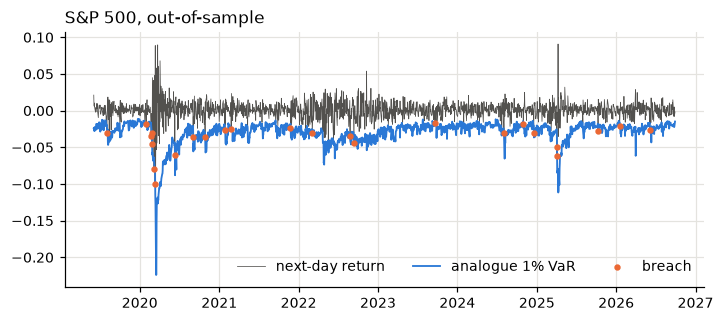

In [4]:
v = out["Analogue"][a][0]
sl = slice(mkt.df.index.get_loc(mkt.df.loc["2019-06-01":].index[0]), mkt.n - 1)
idx, ret, var1 = mkt.df.index[sl], y[sl], v[sl]
breach = ret <= var1
fig, ax = plt.subplots(figsize=(7.5, 3))
ax.plot(idx, ret, color=INK2, lw=0.5, label="next-day return")
ax.plot(idx, var1, color=BLUE, lw=1.2, label="analogue 1% VaR")
ax.scatter(idx[breach], ret[breach], color=ORANGE, s=10, zorder=3, label="breach")
ax.legend(frameon=False, ncol=3); ax.set_title("S&P 500, out-of-sample", loc="left")
plt.show()

Across 24 assets the analogue VaR is as well calibrated as FHS but its expected-shortfall
accuracy is lower; averaging the two recovers FHS-level accuracy (see the paper, H7).